# Volatility-Based Trading Strategy

In this notebook, we convert volatility forecasts and regime information into a simple volatility-aware trading framework.

Objectives:
1. Generate trading signals using volatility regimes
2. Dynamically adjust position sizing
3. Evaluate cumulative strategy performance
4. Compare strategy behavior against benchmark returns

The strategy focuses on volatility-based risk management rather than direct price prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sp500 = pd.read_csv(
    "../data/SP500_processed.csv",
    index_col="Date",
    parse_dates=True
)

In [3]:
sp500["rolling_vol"] = (
    sp500["log_return"]
    .rolling(30)
    .std()
)

In [4]:
threshold = sp500["rolling_vol"].median()

sp500["signal"] = np.where(
    sp500["rolling_vol"] < threshold,
    1,
    0
)

In [5]:
sp500["strategy_return"] = (
    sp500["signal"].shift(1)
    * sp500["log_return"]
)

In [6]:
sp500["cum_market"] = (
    1 + sp500["log_return"]
).cumprod()

sp500["cum_strategy"] = (
    1 + sp500["strategy_return"]
).cumprod()

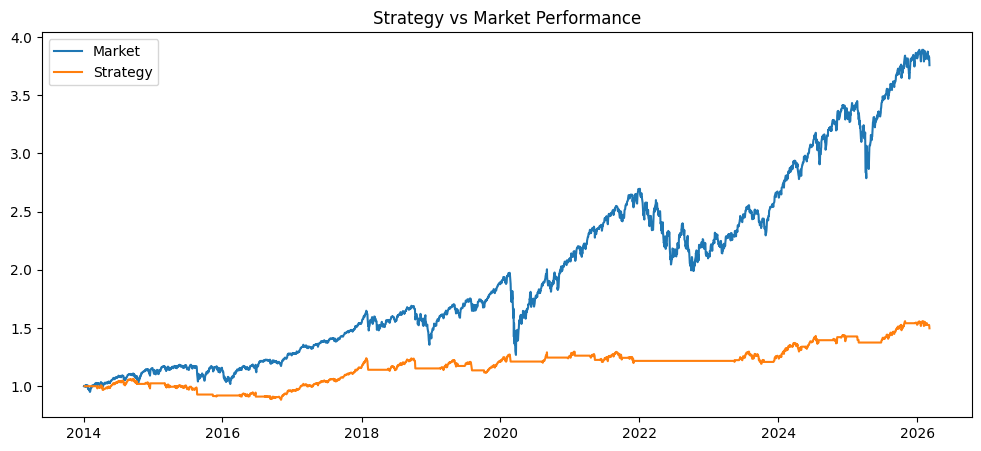

In [7]:
plt.figure(figsize=(12,5))

plt.plot(
    sp500["cum_market"],
    label="Market"
)

plt.plot(
    sp500["cum_strategy"],
    label="Strategy"
)

plt.legend()

plt.title("Strategy vs Market Performance")

plt.show()

## Strategy Interpretation

The volatility-based strategy reduces market exposure during high-volatility periods.

This may reduce downside risk and drawdowns during turbulent market conditions, although it may also underperform during strong bullish periods.

In [8]:
rolling_peak = (
    sp500["cum_strategy"]
    .cummax()
)

In [9]:
drawdown = (
    sp500["cum_strategy"]
    - rolling_peak
) / rolling_peak

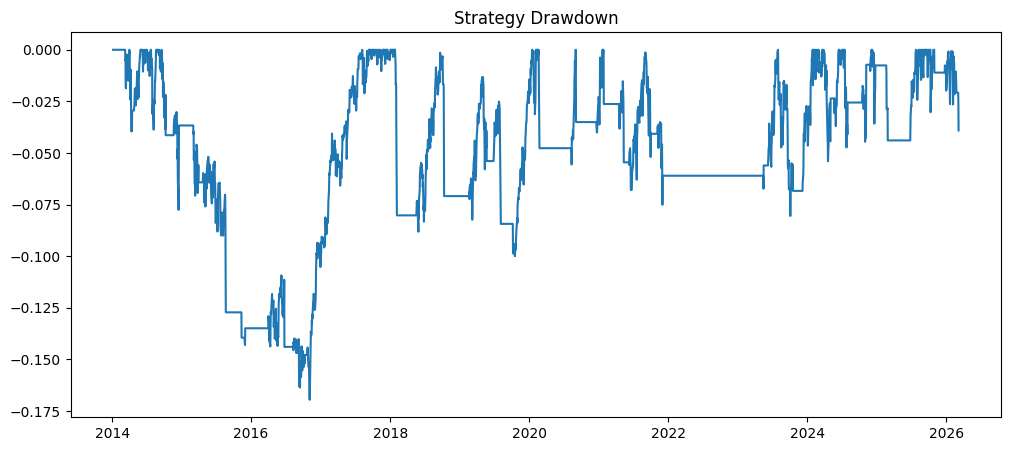

In [10]:
plt.figure(figsize=(12,5))

plt.plot(drawdown)

plt.title("Strategy Drawdown")

plt.show()

## Drawdown Interpretation

The volatility-aware strategy attempts to reduce severe portfolio declines during unstable market periods.

Lower drawdowns indicate improved capital preservation during crises.

# Conclusion

The volatility-based framework demonstrates how volatility information can be integrated into portfolio exposure decisions.

Rather than forecasting exact price movements, the strategy dynamically adjusts risk exposure based on changing market volatility conditions.

This approach connects econometric volatility modeling with practical trading and portfolio management applications.